In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    mean_squared_error, mean_absolute_error, r2_score)


from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestClassifier, RandomForestRegressor,
    GradientBoostingClassifier, GradientBoostingRegressor)
from sklearn.linear_model import LogisticRegression, Ridge

try:
    from xgboost import XGBClassifier, XGBRegressor
    xgboost_available = True
    print("XGBoost available.")
except ImportError:
    xgboost_available = False
    print("XGBoost not installed.")

import os
os.makedirs('plots', exist_ok=True)

random_state = 42
plt.rcParams['figure.dpi'] = 120
sns.set_style('whitegrid')

Mounted at /content/drive
XGBoost available.


In [2]:
data_path = '/content/drive/MyDrive/dsa210/materials_featurized.csv'

df = pd.read_csv(data_path)


## 1.Feature Engineering & Preprocessing
 **factor features**:
- Categorical column `crystal_system`: one-hot encoding
- All continuous features: standardised with `StandardScaler`  
- High-cardinality / identifier columns dropped

In [3]:
drop_cols= ['material_id', 'formula', 'spacegroup', 'total_magnetization_normalized_formula_units', 'total_magnetization']
target_reg= 'magnetization_per_fu'
target_clf= 'ordering'
cat_cols= ['crystal_system']

# One-hot encode categorical features
df_enc = pd.get_dummies(df.drop(columns=[c for c in drop_cols if c in df.columns]),columns=cat_cols, drop_first=False)

feature_cols = [c for c in df_enc.columns
                if c not in [target_reg, target_clf]]

X= df_enc[feature_cols].fillna(0)
y_clf= df_enc[target_clf]
y_reg= df_enc[target_reg]

print(f"Feature matrix : {X.shape}")
print(f"Total features : {len(feature_cols)}")

Feature matrix : (18415, 25)
Total features : 25


In [4]:
X_train, X_temp, y_clf_train, y_clf_temp, y_reg_train, y_reg_temp = train_test_split(X, y_clf, y_reg,
                                                                                     test_size=0.30, random_state=random_state, stratify=y_clf)

X_val, X_test, y_clf_val, y_clf_test, y_reg_val, y_reg_test = train_test_split(X_temp, y_clf_temp, y_reg_temp,
                                                                            test_size=0.50, random_state=random_state, stratify=y_clf_temp)

print(f"Train: {X_train.shape[0]:,}")
print(f"Validation: {X_val.shape[0]:,}")
print(f"Test: {X_test.shape[0]:,}")

#standardise, fit on training set to prevent data leakage
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc = scaler.transform(X_val)
X_test_sc = scaler.transform(X_test)

#encode classification labels
le = LabelEncoder()
y_clf_train_enc = le.fit_transform(y_clf_train)
y_clf_val_enc = le.transform(y_clf_val)
y_clf_test_enc = le.transform(y_clf_test)

print(f"\nLabel encoding: {dict(zip(le.classes_, le.transform(le.classes_)))}")

Train: 12,890
Validation: 2,762
Test: 2,763

Label encoding: {'AFM': np.int64(0), 'FM': np.int64(1), 'FiM': np.int64(2), 'NM': np.int64(3)}



## 2.Classification: Predicting Magnetic Ordering Type

### 2.1 Logistic Regression



In [5]:
lr = LogisticRegression(max_iter=1000, random_state=random_state)
lr.fit(X_train_sc, y_clf_train_enc)
lr_val_acc = accuracy_score(y_clf_val_enc, lr.predict(X_val_sc))
print(f"Logistic Regression, Validation Accuracy: {lr_val_acc:.4f}")

Logistic Regression, Validation Accuracy: 0.5916


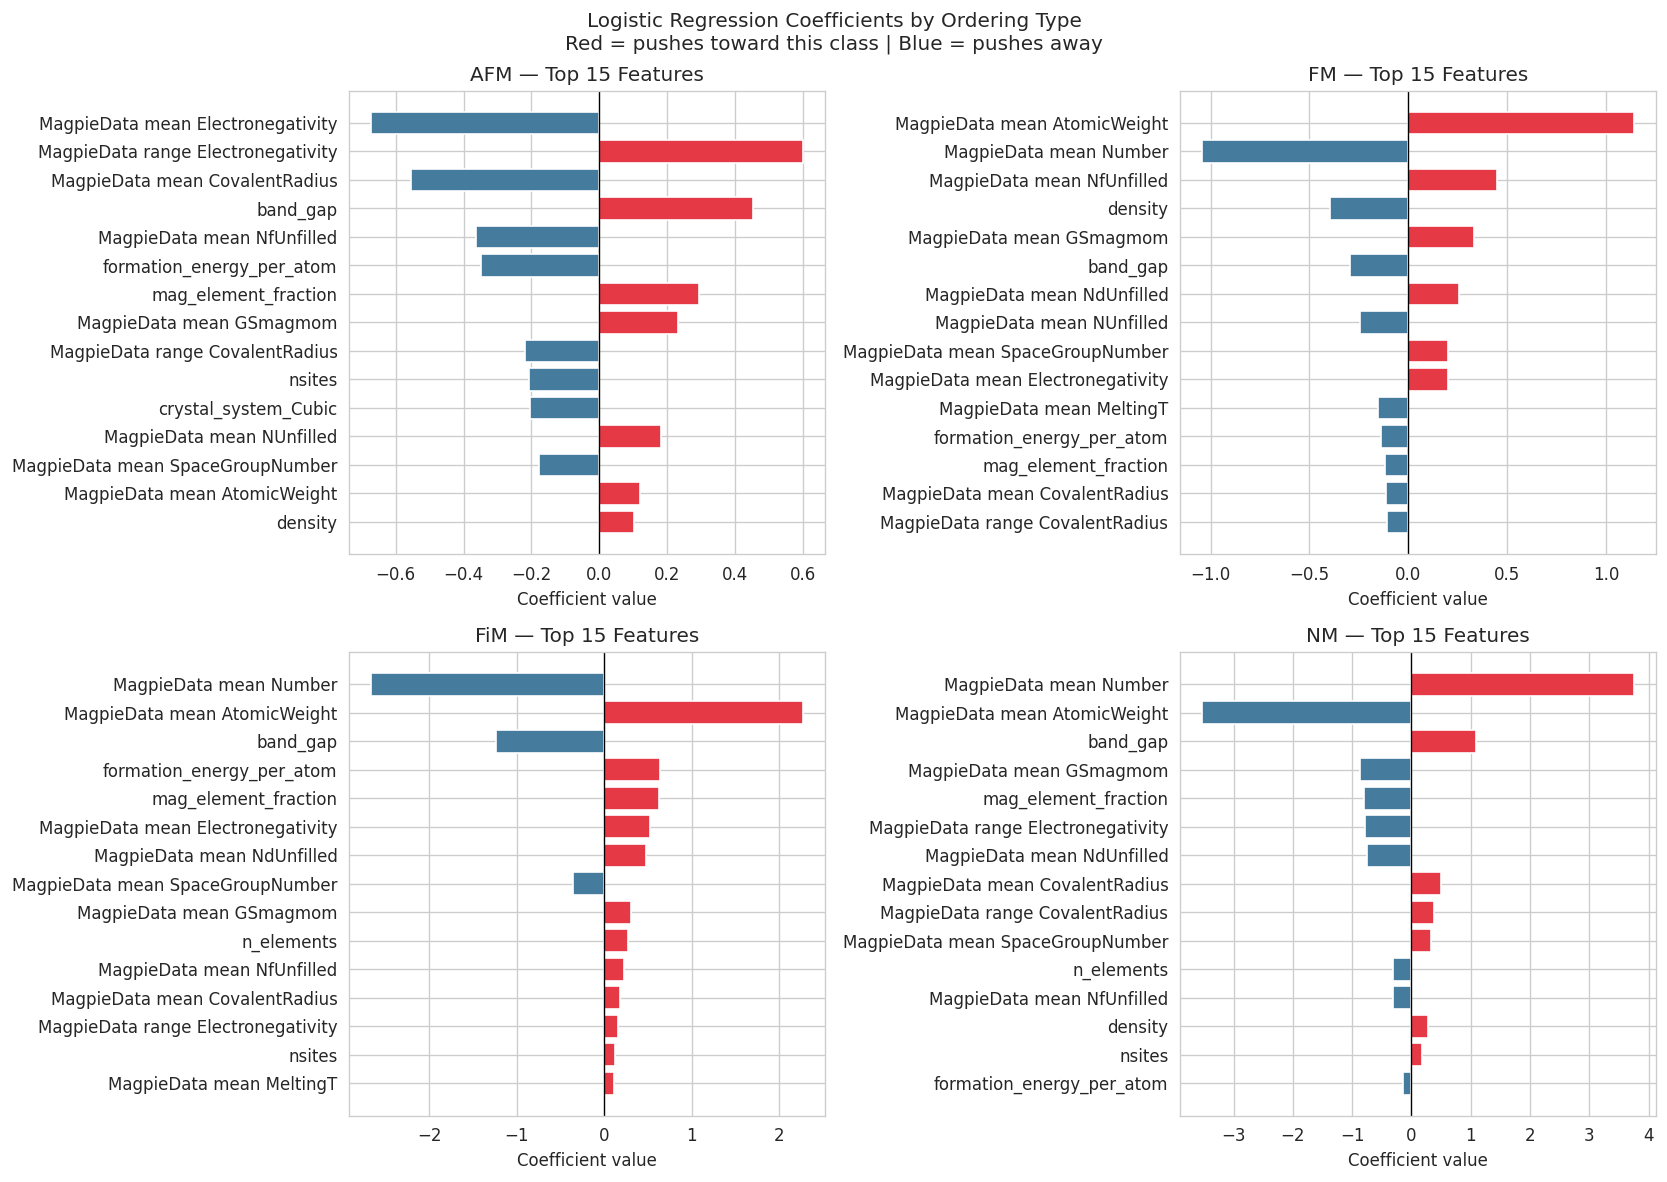

In [6]:
# Plot top 15 most influential features for each class
coef_df =pd.DataFrame(lr.coef_, columns=feature_cols, index=le.classes_)

fig, axes= plt.subplots(2, 2, figsize=(14, 10))
axes =axes.flatten()

for i, ordering in enumerate(le.classes_):
    top = coef_df.loc[ordering].abs().nlargest(15).index
    vals = coef_df.loc[ordering][top]
    colors = ['#e63946' if v > 0 else '#457b9d' for v in vals]

    axes[i].barh(top[::-1], vals[::-1], color=colors[::-1])
    axes[i].axvline(0, color='black', linewidth=0.8)
    axes[i].set_title(f'{ordering} — Top 15 Features')
    axes[i].set_xlabel('Coefficient value')

fig.suptitle('Logistic Regression Coefficients by Ordering Type\n' 'Red = pushes toward this class | Blue = pushes away', fontsize=12)
plt.tight_layout()
plt.savefig('plots/logistic_regression_coefficients.png', bbox_inches='tight')
plt.show()

###2.2 Random Forest

In [7]:
rf_clf = RandomForestClassifier(n_estimators=300, max_features='sqrt', oob_score=True, n_jobs=-1, random_state=random_state)
rf_clf.fit(X_train_sc, y_clf_train_enc)

rf_oob_acc = rf_clf.oob_score_
rf_val_acc = accuracy_score(y_clf_val_enc, rf_clf.predict(X_val_sc))

print(f"OOB Accuracy: {rf_oob_acc:.4f}")
print(f"Validation Accuracy: {rf_val_acc:.4f}")

OOB Accuracy: 0.7054
Validation Accuracy: 0.7234


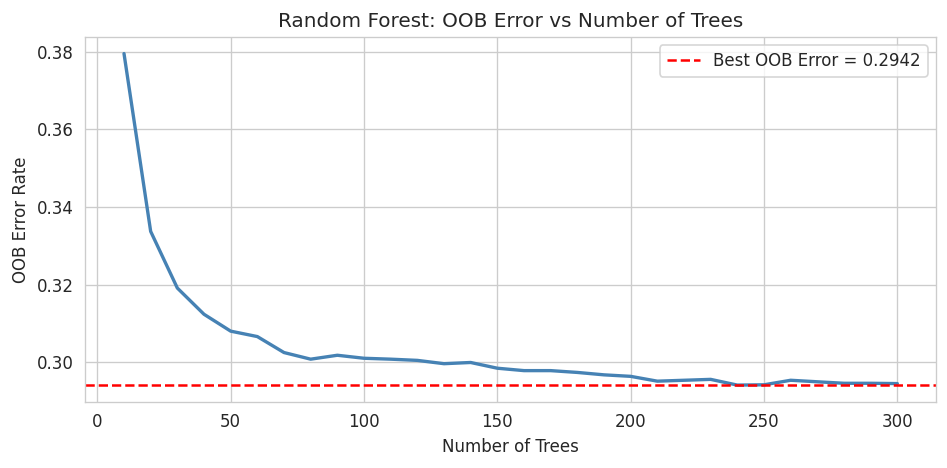

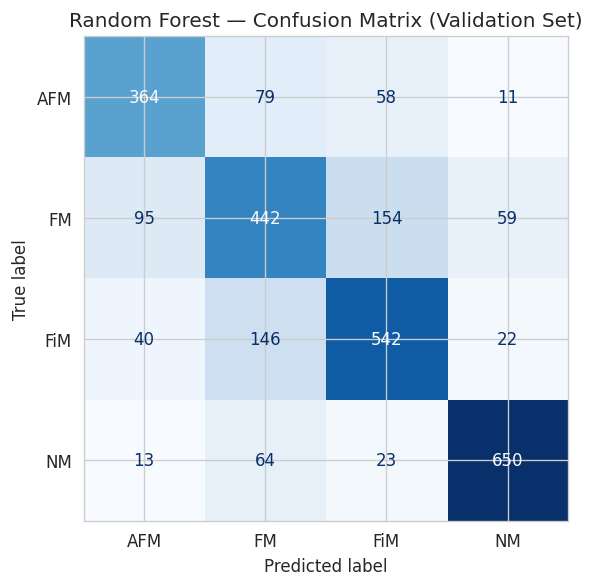

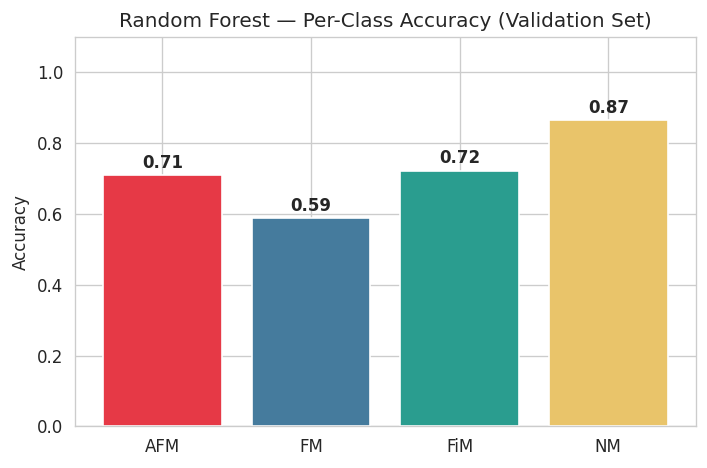

In [9]:
# 1. OOB Error vs Number of Trees
oob_errors = []
for n in range(10, 301, 10):
    rf_temp = RandomForestClassifier(n_estimators=n, max_features='sqrt', oob_score=True, n_jobs=-1, random_state=random_state)
    rf_temp.fit(X_train_sc, y_clf_train_enc)
    oob_errors.append(1 - rf_temp.oob_score_)

plt.figure(figsize=(8, 4))
plt.plot(range(10, 301, 10), oob_errors, color='steelblue', linewidth=2)
plt.xlabel('Number of Trees')
plt.ylabel('OOB Error Rate')
plt.title('Random Forest: OOB Error vs Number of Trees')
plt.axhline(min(oob_errors), color='red', linestyle='--', label=f'Best OOB Error = {min(oob_errors):.4f}')
plt.legend()
plt.tight_layout()
plt.savefig('plots/rf_oob_error.png', bbox_inches='tight')
plt.show()

# 2. Class-level accuracy breakdown
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_clf_val_enc, rf_clf.predict(X_val_sc))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)

fig, ax = plt.subplots(figsize=(7, 5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Random Forest — Confusion Matrix (Validation Set)')
plt.tight_layout()
plt.savefig('plots/rf_confusion_matrix.png', bbox_inches='tight')
plt.show()

# 3. Per-class accuracy
class_acc = cm.diagonal() / cm.sum(axis=1)
plt.figure(figsize=(6, 4))
plt.bar(le.classes_, class_acc, color=['#e63946','#457b9d','#2a9d8f','#e9c46a'], edgecolor='white')
plt.ylabel('Accuracy')
plt.ylim(0, 1.1)
plt.title('Random Forest — Per-Class Accuracy (Validation Set)')
for i, (cls, acc) in enumerate(zip(le.classes_, class_acc)):
    plt.text(i, acc + 0.02, f'{acc:.2f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('plots/rf_per_class_accuracy.png', bbox_inches='tight')
plt.show()

### 2.3 Gradient Boosting

In [10]:
# Each tree is fitted to the residuals of the previous one
# learning_rate=0.1 controls shrinkage
# max_depth=5 keeps individual trees shallow to reduce overfitting
# n_estimators=125, chosen based on learning curve, val accuracy plateaus here

gb_clf = GradientBoostingClassifier(n_estimators=125, learning_rate=0.1, max_depth=5, random_state=random_state)
gb_clf.fit(X_train_sc, y_clf_train_enc)
gb_val_acc = accuracy_score(y_clf_val_enc, gb_clf.predict(X_val_sc))
print(f"Gradient Boosting Validation Accuracy: {gb_val_acc:.4f}")

# eval_set allows monitoring validation accuracy during training
# verbose=False suppresses per-round output
if xgboost_available:
    xgb_clf = XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=5, eval_metric='mlogloss', random_state=random_state, n_jobs=-1)
    xgb_clf.fit(X_train_sc, y_clf_train_enc, eval_set=[(X_val_sc, y_clf_val_enc)], verbose=False)
    xgb_val_acc = accuracy_score(y_clf_val_enc, xgb_clf.predict(X_val_sc))
    print(f"XGBoost Validation Accuracy: {xgb_val_acc:.4f}")

Gradient Boosting Validation Accuracy: 0.6959
XGBoost Validation Accuracy: 0.7031


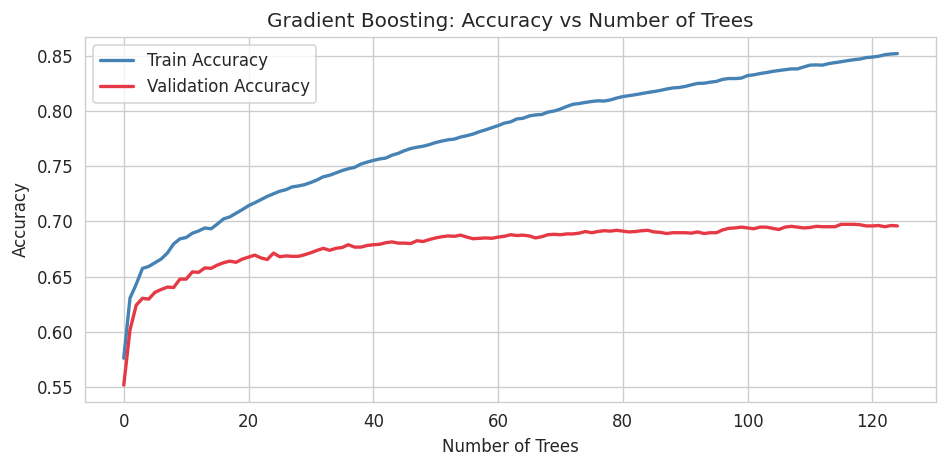

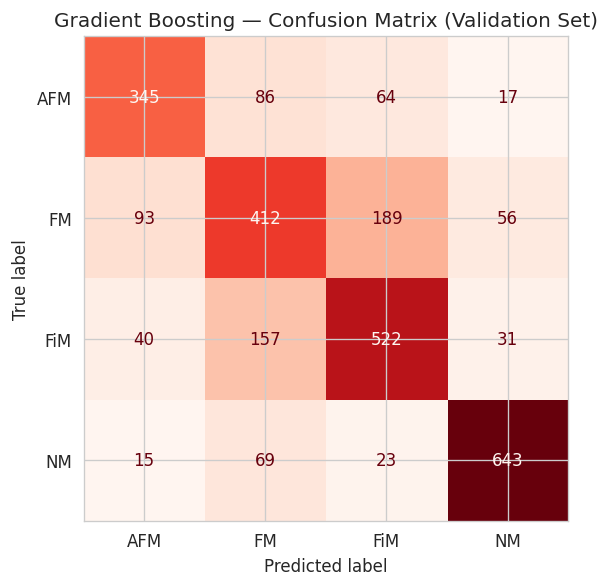

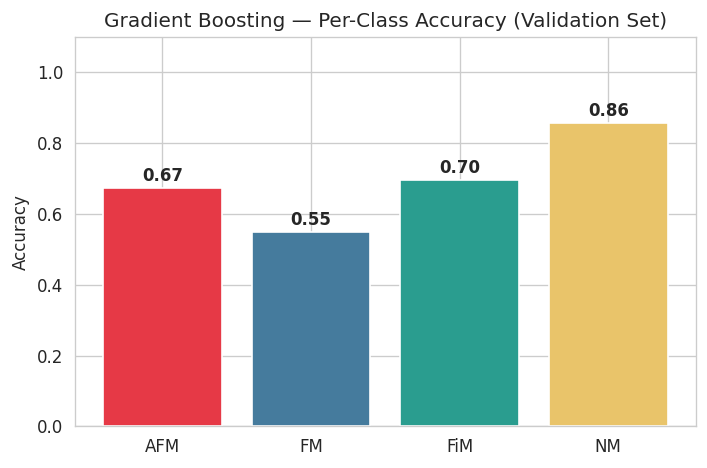

In [11]:
# 1. Training deviance (loss) curve, shows how GB improves over each tree
train_scores = []
val_scores = []

for i, y_pred in enumerate(gb_clf.staged_predict(X_train_sc)):
    train_scores.append(accuracy_score(y_clf_train_enc, y_pred))
for i, y_pred in enumerate(gb_clf.staged_predict(X_val_sc)):
    val_scores.append(accuracy_score(y_clf_val_enc, y_pred))

plt.figure(figsize=(8, 4))
plt.plot(train_scores, label='Train Accuracy', color='steelblue', linewidth=2)
plt.plot(val_scores, label='Validation Accuracy', color='#e63946', linewidth=2)
plt.xlabel('Number of Trees')
plt.ylabel('Accuracy')
plt.title('Gradient Boosting: Accuracy vs Number of Trees')
plt.legend()
plt.tight_layout()
plt.savefig('plots/gb_learning_curve.png', bbox_inches='tight')
plt.show()

# 2. Confusion matrix
cm_gb = confusion_matrix(y_clf_val_enc, gb_clf.predict(X_val_sc))
disp_gb = ConfusionMatrixDisplay(confusion_matrix=cm_gb, display_labels=le.classes_)

fig, ax = plt.subplots(figsize=(7, 5))
disp_gb.plot(ax=ax, cmap='Reds', colorbar=False)
ax.set_title('Gradient Boosting — Confusion Matrix (Validation Set)')
plt.tight_layout()
plt.savefig('plots/gb_confusion_matrix.png', bbox_inches='tight')
plt.show()

# 3. Per-class accuracy
class_acc_gb = cm_gb.diagonal() / cm_gb.sum(axis=1)
plt.figure(figsize=(6, 4))
plt.bar(le.classes_, class_acc_gb,
        color=['#e63946','#457b9d','#2a9d8f','#e9c46a'], edgecolor='white')
plt.ylabel('Accuracy')
plt.ylim(0, 1.1)
plt.title('Gradient Boosting — Per-Class Accuracy (Validation Set)')
for i, (cls, acc) in enumerate(zip(le.classes_, class_acc_gb)):
    plt.text(i, acc + 0.02, f'{acc:.2f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('plots/gb_per_class_accuracy.png', bbox_inches='tight')
plt.show()

### 3. Model Comparison

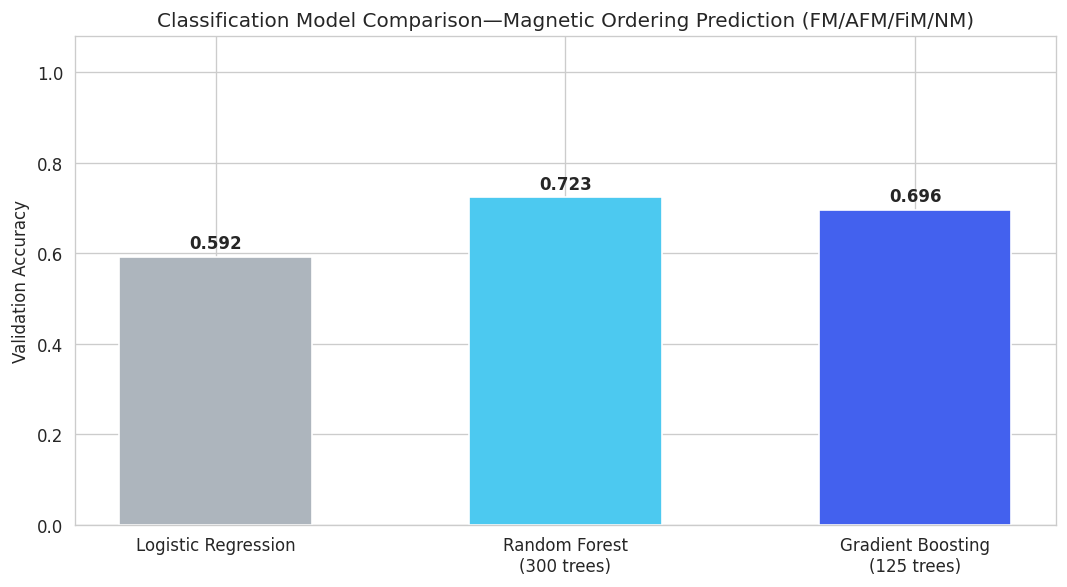

In [12]:
#collect validation accuracies for all three models

clf_results = {
    'Logistic Regression': lr_val_acc,
    'Random Forest\n(300 trees)':      rf_val_acc,
    'Gradient Boosting\n(125 trees)':  gb_val_acc,
}

colors = ['#adb5bd', '#4cc9f0', '#4361ee', '#7209b7', '#f72585']

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(clf_results.keys(), clf_results.values(),
              color=colors, edgecolor='white', width=0.55)
ax.set_ylim(0, 1.08)
ax.set_ylabel('Validation Accuracy')
ax.set_title('Classification Model Comparison—Magnetic Ordering Prediction (FM/AFM/FiM/NM)')
for bar, val in zip(bars, clf_results.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=10)
plt.tight_layout()
plt.savefig('plots/clf_comparison.png', bbox_inches='tight')
plt.show()

### 3.1 Best Classifier: Test Evaluation & Confusion Matrix

Best classifier on validation: Random Forest (300 trees)

Test Accuracy: 0.6942

Classification Report:
              precision    recall  f1-score   support

         AFM       0.69      0.65      0.67       513
          FM       0.57      0.60      0.59       750
         FiM       0.67      0.66      0.66       750
          NM       0.86      0.85      0.85       750

    accuracy                           0.69      2763
   macro avg       0.70      0.69      0.69      2763
weighted avg       0.70      0.69      0.70      2763



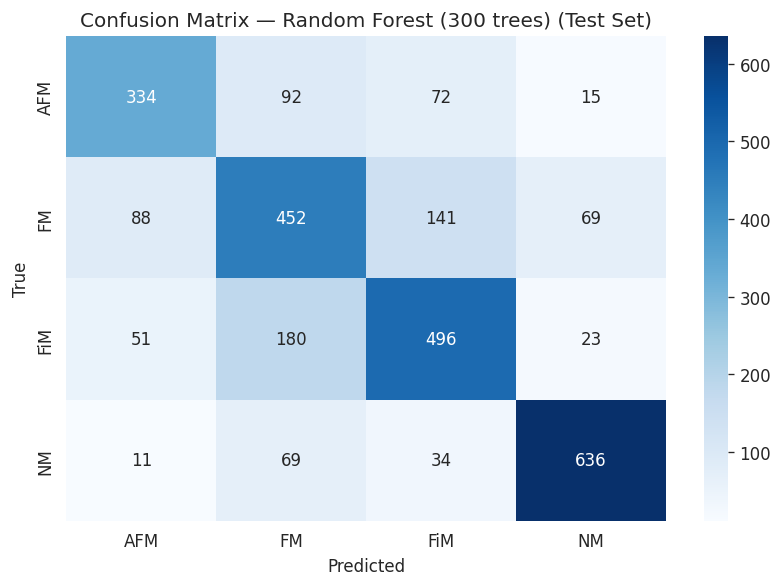

In [13]:
best_clf_name = max(clf_results, key=clf_results.get)
print(f"Best classifier on validation: {best_clf_name.replace(chr(10), ' ')}")

model_map = {
    'Logistic Regression': lr,
    'Random Forest\n(300 trees)':      rf_clf,
    'Gradient Boosting\n(125 trees)':  gb_clf,
}
best_model_clf = model_map[best_clf_name]

y_pred_test = best_model_clf.predict(X_test_sc)
test_acc    = accuracy_score(y_clf_test_enc, y_pred_test)
print(f"\nTest Accuracy: {test_acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_clf_test_enc, y_pred_test, target_names=le.classes_))

cm = confusion_matrix(y_clf_test_enc, y_pred_test)
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title(f'Confusion Matrix — {best_clf_name.replace(chr(10)," ")} (Test Set)')
plt.tight_layout()
plt.savefig('plots/confusion_matrix.png', bbox_inches='tight')
plt.show()

### 4. K-Fold Cross-Validation

5-Fold Cross-Validation Accuracy:
  Fold 1: 0.7126
  Fold 2: 0.7065
  Fold 3: 0.7054
  Fold 4: 0.7051
  Fold 5: 0.7208
  Mean  : 0.7101 ± 0.0060


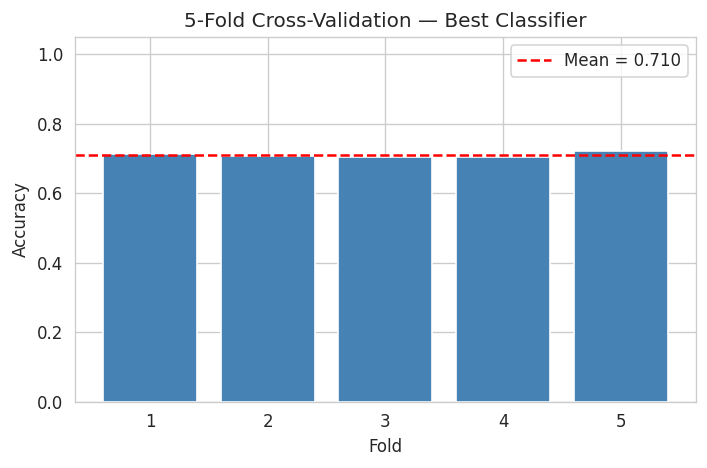

In [15]:
X_trainval = np.vstack([X_train_sc, X_val_sc])
y_trainval  = np.concatenate([y_clf_train_enc, y_clf_val_enc])

cv_scores = cross_val_score(
    best_model_clf, X_trainval, y_trainval,
    cv=5, scoring='accuracy', n_jobs=-1)

print("5-Fold Cross-Validation Accuracy:")
for i, s in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {s:.4f}")
print(f"  Mean  : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

plt.figure(figsize=(6, 4))
plt.bar(range(1, 6), cv_scores, color='steelblue', edgecolor='white')
plt.axhline(cv_scores.mean(), color='red', linestyle='--', label=f'Mean = {cv_scores.mean():.3f}')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.title('5-Fold Cross-Validation — Best Classifier')
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.savefig('plots/cross_validation.png', bbox_inches='tight')
plt.show()


## 4.2 Feature Importance Analysis

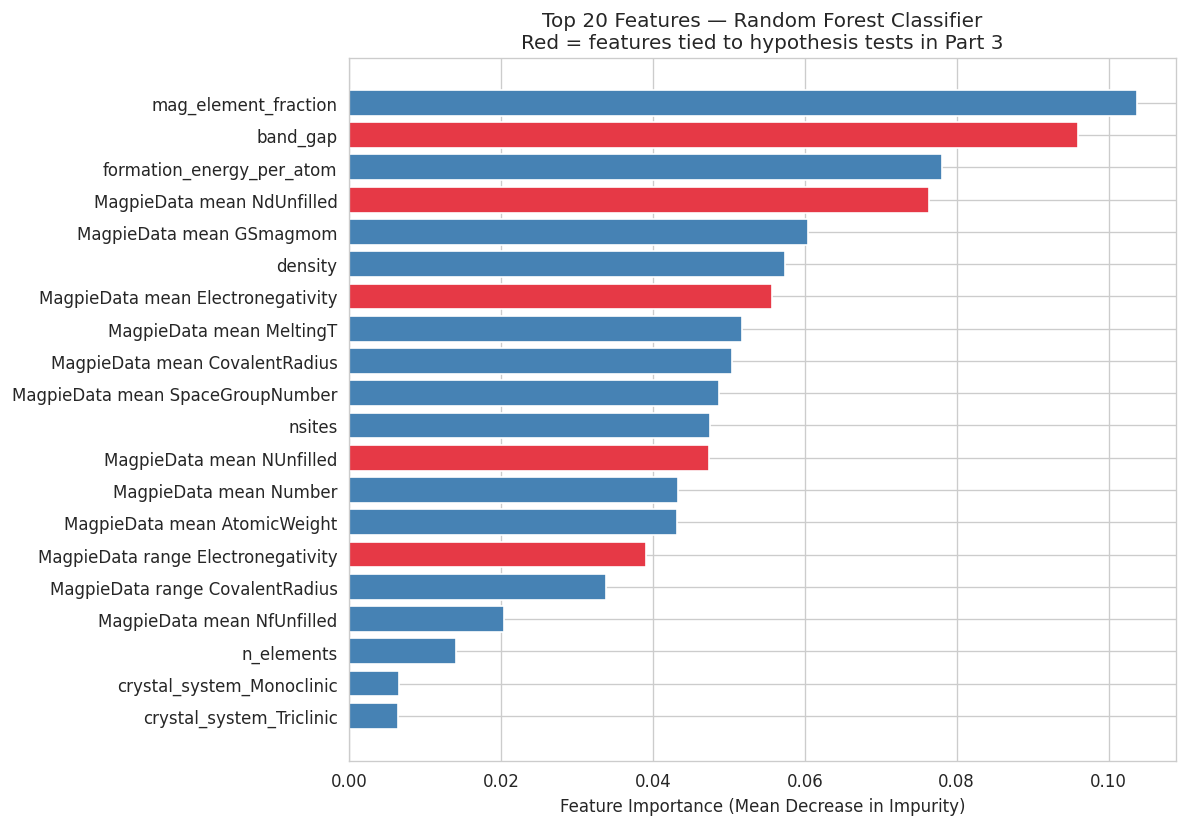

In [16]:
importances  = rf_clf.feature_importances_
feat_imp_df  = pd.DataFrame({'feature': feature_cols, 'importance': importances})
feat_imp_df  = feat_imp_df.sort_values('importance', ascending=False).reset_index(drop=True)

top_n     = 20
top_feats = feat_imp_df.head(top_n)

# Highlight features from hypothesis testing
hypothesis_keywords = ['NdUnfilled', 'NUnfilled', 'magnetic_element', 'band_gap', 'Electronegativity']
colors_fi = ['#e63946' if any(kw in f for kw in hypothesis_keywords) else 'steelblue'
             for f in top_feats['feature']]

plt.figure(figsize=(10, 7))
plt.barh(top_feats['feature'][::-1], top_feats['importance'][::-1],
         color=colors_fi[::-1])
plt.xlabel('Feature Importance (Mean Decrease in Impurity)')
plt.title(f'Top {top_n} Features — Random Forest Classifier\n'
          'Red = features tied to hypothesis tests in Part 3')
plt.tight_layout()
plt.savefig('plots/feature_importance_clf.png', bbox_inches='tight')
plt.show()

In [17]:
# Check ranks of hypothesis-tested features
hypothesis_features = [
    ('H1 — Mean NUnfilled',           'NUnfilled'),
    ('H2 — Mean NdUnfilled',          'NdUnfilled'),
    ('H3 — Band Gap',                 'band_gap'),
    ('H4 — Magnetic Element Fraction','mag_element_fraction'),
]

print("Feature Importance of Hypothesis-Tested Features:")
print("-" * 65)
for label, keyword in hypothesis_features:
    matches = feat_imp_df[feat_imp_df['feature'].str.contains(keyword, case=False)]
    if not matches.empty:
        top_match = matches.iloc[0]
        rank = feat_imp_df.index[feat_imp_df['feature'] == top_match['feature']].tolist()[0] + 1
        print(f"{label:45s} → Rank #{rank:3d}  |  Importance: {top_match['importance']:.5f}")
    else:
        print(f"{label:45s} → Feature not found")

Feature Importance of Hypothesis-Tested Features:
-----------------------------------------------------------------
H1 — Mean NUnfilled                           → Rank # 12  |  Importance: 0.04743
H2 — Mean NdUnfilled                          → Rank #  4  |  Importance: 0.07637
H3 — Band Gap                                 → Rank #  2  |  Importance: 0.09603
H4 — Magnetic Element Fraction                → Rank #  1  |  Importance: 0.10369
